# M01. Batted Balls

### Imports

In [1]:
from DataImports import *

Batted Ball Angle Note:
- if y > 198.27 and x < 125.42), it's actually to left
- if y > 198.27 and x > 125.42), it's actually to right

### Settings

In [ ]:
train_batted_ball_model = False    # Train model (Shouldn't need to be run often)
start_year, end_year = 2015, 2025  # Years to include in the batted ball dataset    
num_games = 243                    # Number of games to roll for PFX calculations
short, long = 50, 300              # Number of PAs to roll for short and long term rates

### Data

##### MLB Stats API

Merge MLB Stats API and Statcast data

In [3]:
df = merge_datasets(start_year, end_year)
df = clean_weather(df)
df = create_events(df)
df = create_variables(df)
df = start_data(df)

##### Steamer

In [4]:
steamer_hitters_df = pd.read_csv(os.path.join(baseball_path, "A03. Steamer", "steamer_hitters_weekly_log.csv"), encoding='iso-8859-1', usecols=['proj_date', 'mlbamid', 'PA', 'UBR'], dtype='str')

### Clean

##### MLB Stats API

Format data types for merge

In [5]:
df['proj_date'] = pd.to_datetime(df['date'], format='%Y%m%d')

In [6]:
df['mlbamid'] = df['batter'].astype(str)

Sent launch data to 0 if not batted

In [7]:
df[['launch_angle', 'launch_speed']] = df[['launch_angle', 'launch_speed']].fillna(0)

##### Steamer

Convert data types

In [8]:
steamer_hitters_df[['PA', 'UBR']] = steamer_hitters_df[['PA', 'UBR']].astype(float)

In [9]:
steamer_hitters_df['proj_date'] = pd.to_datetime(steamer_hitters_df['proj_date'])

Calculate UBR per 600 Plate Appearances

In [10]:
steamer_hitters_df['UBR600'] = steamer_hitters_df['UBR'] / steamer_hitters_df['PA'] * 600

### Merge

In [11]:
df = pd.merge_asof(
    df.sort_values('proj_date'),
    steamer_hitters_df.sort_values('proj_date'),
    by='mlbamid',
    on='proj_date',
    direction='backward'
)

### Inputs

In [12]:
batted_ball_inputs = ['launch_angle', 'launch_speed', 'to_l', 'to_lc', 'to_c', 'to_rc', 'to_r', 'b_L', 'UBR600'] + ['bb', 'hbp', 'so']

### Sample

Remove atypical events and missings

In [13]:
df = df[~df['eventsModel'].isin(["Cut"])].dropna(subset=batted_ball_inputs)

Define model input and outputs

In [14]:
X = df[batted_ball_inputs].values
y = df[['eventsModel']].values

### Model

Probability of events given how the baseball was launched, where it was launched to, and some information about the batter, including handedness and base running. Notably excluding park and weather.

$ \hat{\text{eventsModel}} = launch\_angle + launch\_speed + to\_l + to\_lc + to\_c + to\_rc + to\_r + b\_L + UBR600 $

##### Encode

In [15]:
if not hasattr(sys.modules['__main__'], '__file__') and train_batted_ball_model == True:
    # One-hot eventsModel
    encode_outcome = OneHotEncoder(sparse_output=False)
    # Fit and transform
    y_encoded = encode_outcome.fit_transform(y)
    # Create folder
    os.makedirs(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate), exist_ok=True)   
    # Save
    pickle.dump(encode_outcome, open(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, "encode_outcome.pkl"), 'wb'))
else:
    y_encoded = encode_outcome.transform(y)

##### Scale

In [16]:
if not hasattr(sys.modules['__main__'], '__file__') and train_batted_ball_model == True:
    # Scale model inputs
    scale_inputs = StandardScaler()
    # Fit and transform
    X_scaled = scale_inputs.fit_transform(X)
    # Save
    pickle.dump(scale_inputs, open(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, "scale_inputs.pkl"), 'wb'))
else:
    X_scaled = scale_inputs.transform(X)

##### Train

In [17]:
if not hasattr(sys.modules['__main__'], '__file__') and train_batted_ball_model == True:
    # Create neural network
    predict_outcome = Sequential([
        Dense(32, input_shape=(X_scaled.shape[1],), activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(y_encoded.shape[1], activation='softmax')])
    # Compile
    predict_outcome.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    # Add early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True)
    # Fit
    predict_outcome.fit(
        X_scaled, y_encoded,
        epochs=50,
        batch_size=128,
        validation_split=0.2,
        callbacks=[early_stop])
    # Save
    predict_outcome.save(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, 'predict_outcome.keras'))

##### Predict

Predict rates of events based on batted-ball data

In [18]:
prediction_df = pd.DataFrame(predict_outcome.predict(X_scaled), columns=encode_outcome.categories_[0])
prediction_df = prediction_df.add_suffix('_pred_batted')

58521/58521 ━━━━━━━━━━━━━━━━━━━━ 27s 467us/step


Concatenate predictions onto plate appearance dataset

In [19]:
batted_ball_dataset = pd.concat([df.reset_index(drop=True), prediction_df], axis=1)

Write to CSV

In [20]:
# batted_ball_dataset.to_csv(os.path.join(baseball_path, "Batted Ball Dataset.csv"), index=False)  ## DOn't think I need this to be saved

##### Evaluate

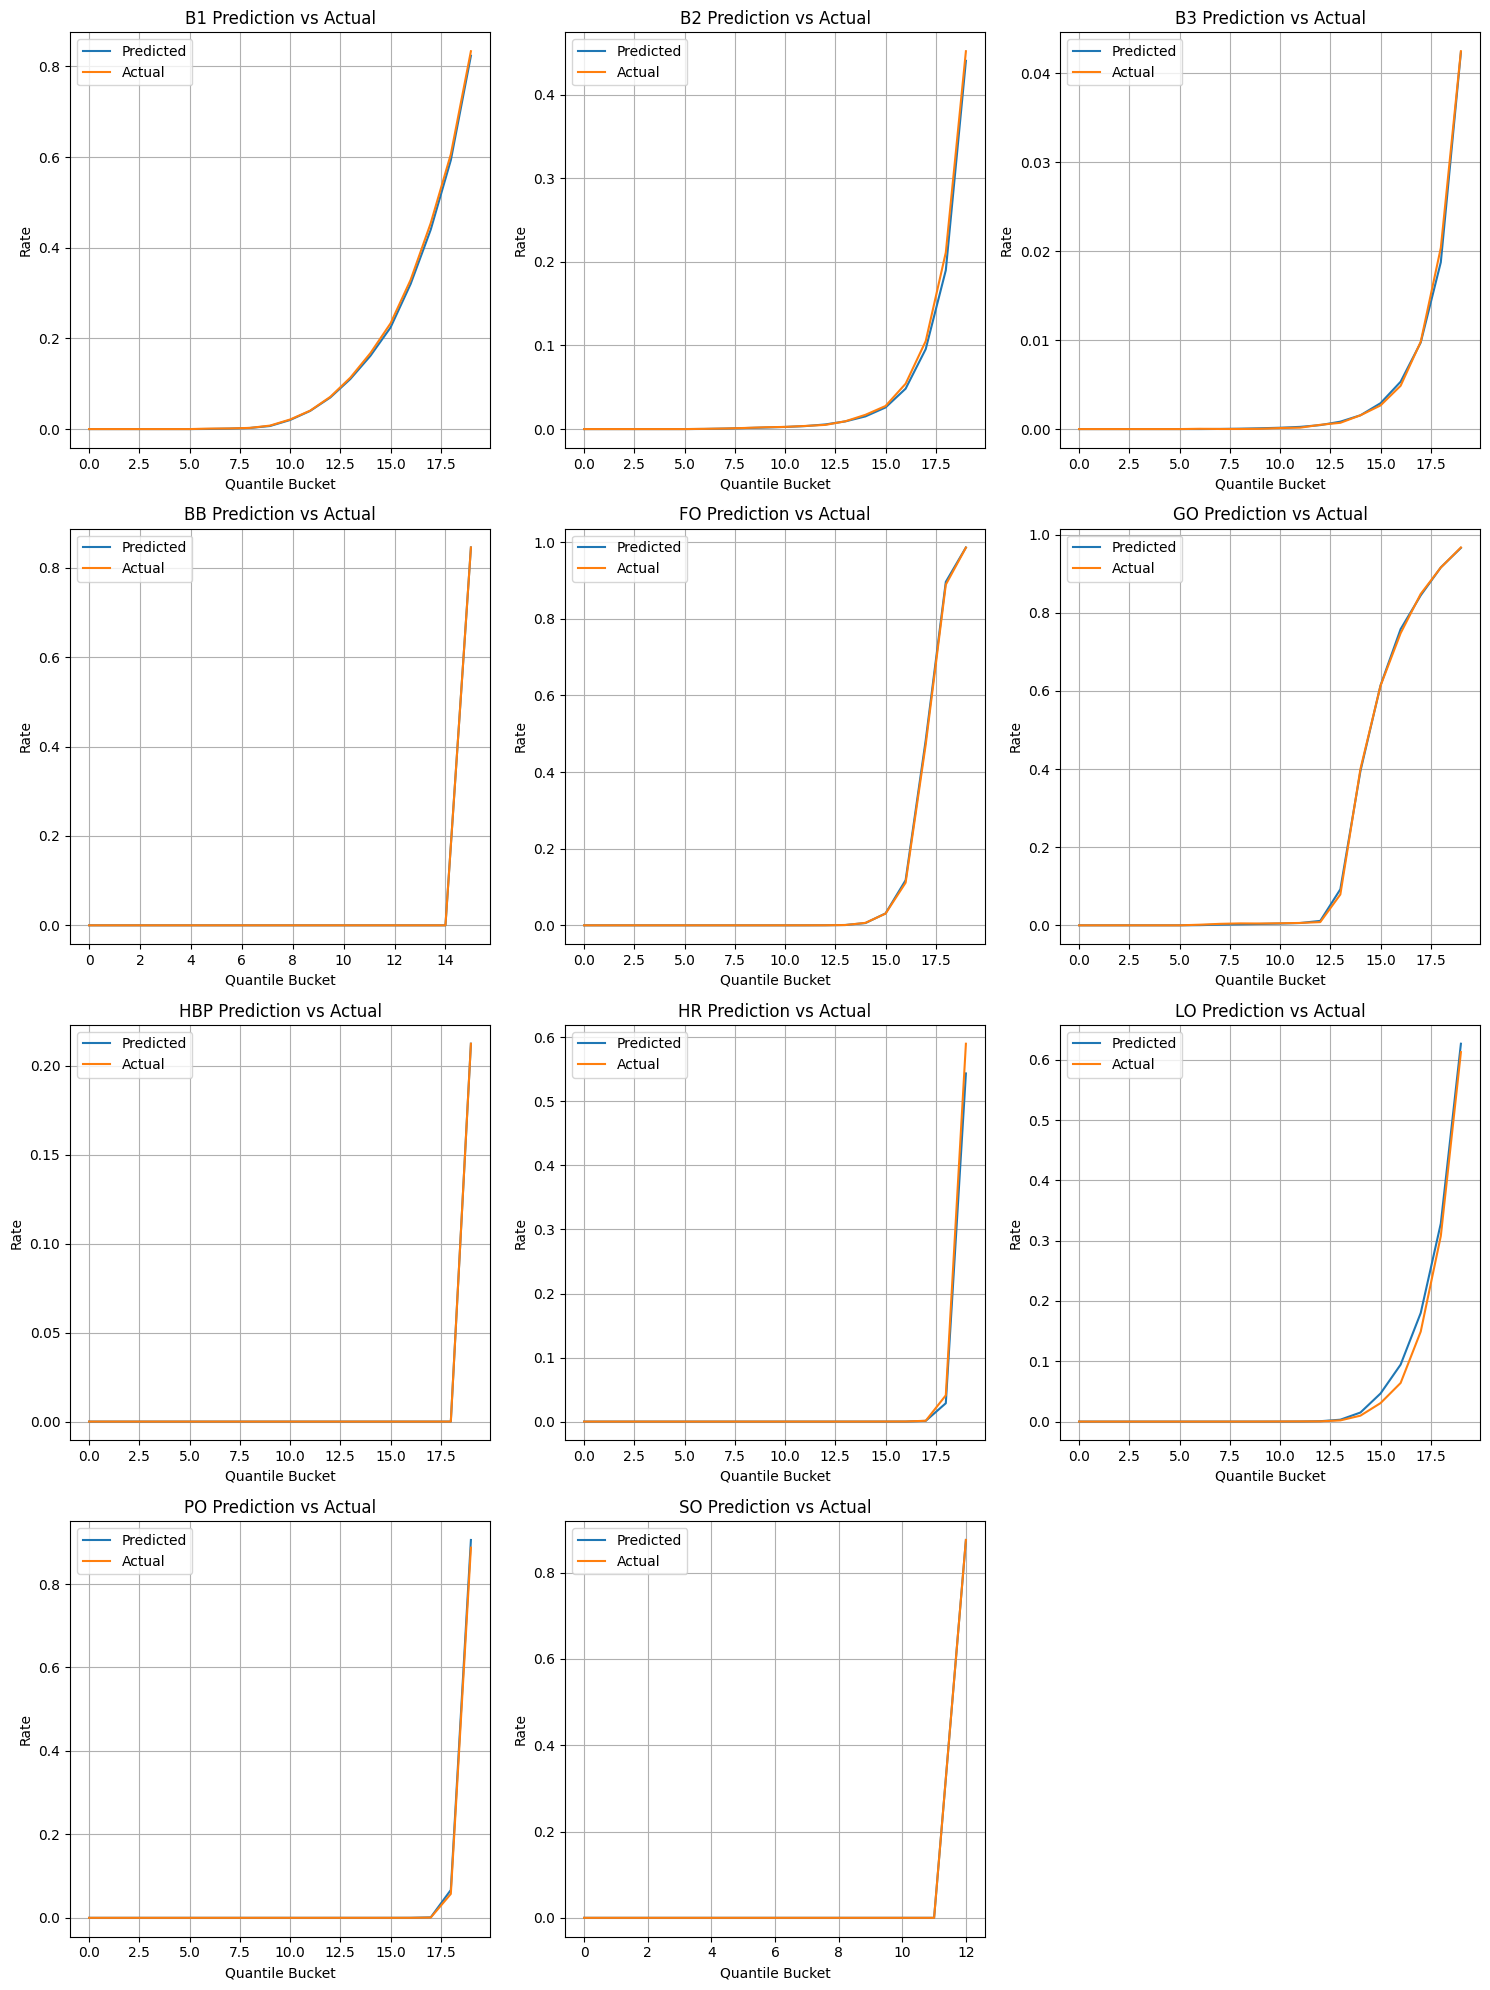

In [21]:
# Adjust the number of rows and columns
n_events = len(events_list)
n_cols = 3
n_rows = (n_events + n_cols - 1) // n_cols  # Ceiling division

# Set square plots: each subplot is 5x5 inches
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, event in enumerate(events_list):
    ax = axes[i]
    pred_col = f"{event}_pred_batted"
    
    if pred_col not in batted_ball_dataset.columns:
        continue

    # Bucket the predicted values into quantiles
    batted_ball_dataset['bucket'] = pd.qcut(batted_ball_dataset[pred_col], q=20, duplicates='drop')

    # Compute averages
    bucket_avg = batted_ball_dataset.groupby('bucket').agg(
        avg_pred=(pred_col, 'mean'),
        avg_actual=(event, 'mean')
    ).reset_index()

    # Plot
    ax.plot(bucket_avg['avg_pred'], label='Predicted')
    ax.plot(bucket_avg['avg_actual'], label='Actual')
    ax.set_title(f"{event.upper()} Prediction vs Actual")
    ax.set_xlabel("Quantile Bucket")
    ax.set_ylabel("Rate")
    ax.legend()
    ax.grid(True)

# Remove extra axes if any
for j in range(n_events, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Calculate PFX

Create lists for containing batted ball predicted outcome rates and PFX

In [22]:
events_list_pred_batted = [f"{event}_pred_batted" for event in events_list]
pfx_list = [f"{event}_pfx" for event in events_list]

Calculate average actual event rates and predicted event rates by game and batSide

In [23]:
game_pfx_df = batted_ball_dataset.groupby(['venue_id', 'gamePk', 'batSide', 'date'])[events_list + events_list_pred_batted].mean().reset_index().sort_values(['venue_id', 'date', 'batSide'])

##### Unshifted

Rolling average of last num_games, including the current game <br>
The last values here for each park are the most recent park factors

In [24]:
# Compute the rolling average of the last num_games *including* the current row
rolling_avgs = (game_pfx_df.groupby(['venue_id', 'batSide'], group_keys=False).apply(lambda group: group[events_list + events_list_pred_batted].shift(0).rolling(num_games, min_periods=1).mean()))

# Rename columns to indicate they are rolling averages
rolling_avgs.columns = [f'{col}_rolling' for col in events_list + events_list_pred_batted]

# Concatenate with the original dataframe
unshifted_game_pfx_df = pd.concat([game_pfx_df, rolling_avgs], axis=1)

for event in events_list:
    unshifted_game_pfx_df[f'{event}_pfx'] = unshifted_game_pfx_df[f'{event}_rolling'] / unshifted_game_pfx_df[f'{event}_pred_batted_rolling']

Write to CSV

In [25]:
unshifted_game_pfx_df[['venue_id', 'batSide'] + [col for col in unshifted_game_pfx_df if col.endswith("pfx")]].drop_duplicates(subset=['venue_id', 'batSide'], keep='last').to_csv(os.path.join(baseball_path, "Park Latest.csv"), index=False)

##### Shifted

Rolling average of last num_games, excluding the current game <br>
These are the park factors coming into the games

In [26]:
# Compute the rolling average of the last num_games *excluding* the current row
rolling_avgs = (game_pfx_df.groupby(['venue_id', 'batSide'], group_keys=False).apply(lambda group: group[events_list + events_list_pred_batted].shift(1).rolling(num_games, min_periods=1).mean()))

# Rename columns to indicate they are rolling averages
rolling_avgs.columns = [f'{col}_rolling' for col in events_list + events_list_pred_batted]

# Concatenate with the original dataframe
shifted_game_pfx_df = pd.concat([game_pfx_df, rolling_avgs], axis=1)

for event in events_list:
    shifted_game_pfx_df[f'{event}_pfx'] = shifted_game_pfx_df[f'{event}_rolling'] / shifted_game_pfx_df[f'{event}_pred_batted_rolling']

Write to CSV

In [27]:
shifted_game_pfx_df.to_csv(os.path.join(baseball_path, "PFX.csv"), index=False)

### Plate Appearance Dataset

This creates a dataset with PA-level data used in several subsequent models

Replace actual event rates with predicted ones

In [28]:
batted_ball_dataset[events_list] = batted_ball_dataset[events_list_pred_batted].copy()

Drop unneeded columns

In [29]:
if 'bucket' in list(batted_ball_dataset.columns):
    batted_ball_dataset.drop(columns=['bucket'], inplace=True)

Calculate rolling stats

Short

In [30]:
df_short = rolling_pas(batted_ball_dataset, short, events_list)

Long

In [31]:
df_long = rolling_pas(batted_ball_dataset, long, events_list)
df_long = df_long.add_suffix("_long")

Merge long stats onto rolling (and other) stats

In [32]:
pa_dataset = pd.concat([df_short, df_long[batter_stats_long + pitcher_stats_long]], axis=1)  # Only need to take the rolling stats from long since the rest are in short
pa_dataset.sort_values(['date', 'gamePk', 'atBatIndex'], ascending=True, inplace=True)
pa_dataset.drop(columns=events_list + ['Cut'], inplace=True)

Add event dummies

In [33]:
event_dummies = pd.get_dummies(pa_dataset['eventsModel']).astype(int)

In [34]:
pa_dataset = pd.concat([pa_dataset, event_dummies], axis=1)

Clean

In [35]:
pa_dataset = pa_dataset.replace([float('inf'), float('-inf')], 0)

Write to CSV

In [36]:
pa_dataset.to_csv(os.path.join(baseball_path, "PA Dataset.csv"), index=False)

In [37]:
print(f"Data as of {pa_dataset['date'].max()}.")

Data as of 20250928.


### Required Follow-Ups:
- Model A. Batted Ball
    - Model B. Park and Weather Factors
    - B01. Matchups
    - M02. Stat Imputations
    - M03. Plate Appearances
- Model B. Park and Weather Factors
    - M03. Plate Appearances

Note: You should avoid rerunning Model A. Batted Ball as much as possible. It's slow. Likely shouldn't need many updates anyway. 